# P2 - Mortgage Approval Prediction & Fair Lending Audit
## Notebook 1: Data Exploration - Problem Discovery - Cleaning - Validation - EDA

**Approach:** Iterative. We explore first, document every problem found, make explicit cleaning decisions, then validate those decisions before doing any analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)

DATA_PATH = '../data/state_CA.csv'
print('Setup complete')

Setup complete


---
# CYCLE 1 - Raw Data Exploration
**Goal:** Understand what is actually in the file before making any decisions.

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df_raw.shape}  ({df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns)')
print(f'Memory:    {df_raw.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'\nDtype breakdown:')
print(df_raw.dtypes.value_counts())

Raw shape: (962073, 99)  (962,073 rows × 99 columns)


Memory:    1835 MB

Dtype breakdown:
int64      39
float64    33
object     27
Name: count, dtype: int64


In [ ]:
# action_taken - what outcomes exist and how many?
action_labels = {
    1: 'Originated (approved + funded)',
    2: 'Approved, not accepted',
    3: 'Denied',
    4: 'Withdrawn by applicant',
    5: 'File closed - incomplete',
    6: 'Purchased loan',
    7: 'Preapproval denied',
    8: 'Preapproval approved, not accepted'
}
ac = df_raw['action_taken'].value_counts().rename(index=action_labels)
print('action_taken distribution (ALL records):')
print(ac.to_string())
print(f'\nWe want: Originated (1) + Denied (3) = {df_raw["action_taken"].isin([1,3]).sum():,} rows')
print('Drop: Withdrawn/Incomplete/Purchased - these are NOT lender decisions')

In [4]:
# loan_purpose, loan_type, lien_status
purpose_labels = {1:'Home purchase', 2:'Home improvement', 31:'Refi-cash out', 32:'Refi-no cash out', 4:'Other', 5:'N/A'}
type_labels    = {1:'Conventional', 2:'FHA', 3:'VA', 4:'FSA/RHS'}
lien_labels    = {1:'First lien', 2:'Subordinate'}

print('loan_purpose:')
print(df_raw['loan_purpose'].value_counts().rename(index=purpose_labels).to_string())
print('\nloan_type:')
print(df_raw['loan_type'].value_counts().rename(index=type_labels).to_string())
print('\nlien_status:')
print(df_raw['lien_status'].value_counts().rename(index=lien_labels).to_string())

loan_purpose:
loan_purpose
Home purchase       464679
Refi-no cash out    158093
Home improvement    122368
Other               120201
Refi-cash out        79342
N/A                  17390

loan_type:
loan_type
Conventional    807536
FHA             114685
VA               39004
FSA/RHS            848

lien_status:
lien_status
First lien     682754
Subordinate    279319


In [5]:
# Apply scope filter and examine what we're left with
df = df_raw[
    (df_raw['action_taken'].isin([1, 3])) &
    (df_raw['loan_purpose'] == 1) &
    (df_raw['loan_type'] == 1) &
    (df_raw['lien_status'] == 1)
].copy()

df['approved'] = (df['action_taken'] == 1).astype(int)

print(f'After filter: {df.shape[0]:,} rows  ({df.shape[0]/df_raw.shape[0]:.1%} of raw)')
print(f'Approved: {df["approved"].sum():,}  ({df["approved"].mean():.1%})')
print(f'Denied:   {(df["approved"]==0).sum():,}  ({1-df["approved"].mean():.1%})')

After filter: 210,315 rows  (21.9% of raw)
Approved: 184,254  (87.6%)
Denied:   26,061  (12.4%)


---
# CYCLE 2 - Problem Discovery
**Goal:** Find every data quality issue before touching the data. Document each one.

In [ ]:
# PROBLEM 1: Mixed units
# income is in $K (thousands). loan_amount and property_value are in $.
# This is standard HMDA format - must not mix them in ratio features.

df['income']         = pd.to_numeric(df['income'], errors='coerce')
df['loan_amount']    = pd.to_numeric(df['loan_amount'], errors='coerce')
df['property_value'] = pd.to_numeric(df['property_value'], errors='coerce')

print('Units check (first 5 rows):')
print(df[['income','loan_amount','property_value']].head())
print(f'\nMedian income:         ${df["income"].median():.0f}K')
print(f'Median loan_amount:    ${df["loan_amount"].median()/1000:.0f}K  (in $, stored as full dollar)')
print(f'Median property_value: ${df["property_value"].median()/1000:.0f}K  (in $, stored as full dollar)')
print('\n>>> DECISION: convert loan_amount and property_value to $K for consistent ratio features')

In [ ]:
# PROBLEM 2: Negative and zero income
print(f'Negative income rows: {(df["income"] < 0).sum()}')
print(f'Zero income rows:     {(df["income"] == 0).sum()}')
print(f'Null income rows:     {df["income"].isna().sum()}')

print('\nApproval breakdown for negative income rows:')
print(df[df['income'] < 0]['approved'].value_counts())
print('\nApproval breakdown for zero income rows:')
print(df[df['income'] == 0]['approved'].value_counts())
print('\n>>> DECISION: negative income (83 rows) -> data error, drop. Zero income (1500) -> plausible for some loan types, but nonsensical for a debt-to-income model -> drop.')

In [ ]:
# PROBLEM 3: Extreme income outliers
print('Income percentiles:')
for p in [95, 99, 99.5, 99.9, 100]:
    v = df['income'].quantile(p/100)
    print(f'  P{p}: ${v:.0f}K')

# How many rows above $5000K ($5M annual income)?
n_extreme = (df['income'] > 5000).sum()
print(f'\nIncome > $5M/yr: {n_extreme} rows ({n_extreme/len(df):.2%})')
print('>>> DECISION: cap income at 99.5th percentile - extreme outliers will dominate scaling without capping')

In [ ]:
# PROBLEM 4: LTV > 100
df['loan_to_value_ratio'] = pd.to_numeric(df['loan_to_value_ratio'], errors='coerce')
print(f'LTV > 100: {(df["loan_to_value_ratio"] > 100).sum()} rows')
print(f'LTV > 200: {(df["loan_to_value_ratio"] > 200).sum()} rows')
print(f'Max LTV: {df["loan_to_value_ratio"].max():.1f}')
print(f'\nLTV > 100 denial rate: {1 - df[df["loan_to_value_ratio"]>100]["approved"].mean():.1%}')
print('\nDistribution of LTV > 100 values:')
high_ltv = df[df['loan_to_value_ratio'] > 100]['loan_to_value_ratio']
print(high_ltv.describe())
print('\n>>> DECISION: LTV slightly above 100 (e.g. 101-120) is legitimate (piggyback loans, fees rolled in). LTV > 200 is almost certainly a data error. Cap at 100.5th percentile of valid range (approx 200).')

In [ ]:
# PROBLEM 5: DTI is mixed-format (buckets + integers + 'Exempt')
print('DTI raw value counts:')
print(df['debt_to_income_ratio'].value_counts().to_string())
print('\n>>> PROBLEM: DTI mixes string buckets (<20%, 20%-<30%, 50%-60%, >60%) with integer strings (36-49) and Exempt.')
print('>>> DECISION: map to numeric midpoints. Exempt -> NaN (not missing at random - check). Create dti_missing_flag to preserve MNAR signal.')

In [ ]:
# PROBLEM 6: MNAR - DTI missing more for denied loans
dti_miss_by_outcome = df.groupby('approved')['debt_to_income_ratio'].apply(
    lambda x: x.isnull().mean()
).rename({0: 'Denied', 1: 'Approved'})
print('DTI null rate by outcome:')
print(dti_miss_by_outcome)

exempt_by_outcome = df.groupby('approved')['debt_to_income_ratio'].apply(
    lambda x: (x.astype(str) == 'Exempt').mean()
).rename({0: 'Denied', 1: 'Approved'})
print('\nDTI "Exempt" rate by outcome:')
print(exempt_by_outcome)
print('\n>>> FINDING: DTI is missing 7.95% for denied vs 5.88% for approved. Lenders sometimes deny without completing underwriting - the missingness is a signal of denial risk. Keep as feature via dti_missing_flag.')

In [ ]:
# PROBLEM 7: Post-origination leakage fields
leakage_cols = ['rate_spread', 'interest_rate', 'total_loan_costs',
                'origination_charges', 'discount_points', 'lender_credits']
print('Population rate (non-null) by outcome for post-origination fields:')
for col in leakage_cols:
    if col in df.columns:
        pop = df.groupby('approved')[col].apply(
            lambda x: pd.to_numeric(x, errors='coerce').notna().mean()
        ).rename({0:'Denied', 1:'Approved'})
        print(f'  {col}: Denied={pop.get(0,0):.1%}  Approved={pop.get(1,0):.1%}')
print('\n>>> CRITICAL: rate_spread and interest_rate are 0% populated for denied loans - they only exist post-origination. Including them would mean the model learns "null = denied" rather than actual underwriting signals. MUST EXCLUDE from model features.')

In [ ]:
# PROBLEM 8: 'Race Not Available' is 24.7% of data
race_dist = df['derived_race'].value_counts()
print('derived_race distribution:')
print(race_dist.to_string())
print(f'\n"Race Not Available": {race_dist.get("Race Not Available",0)/len(df):.1%} of data')
print(f'"Joint" (multiple applicants, different races): {race_dist.get("Joint",0)/len(df):.1%}')
print('\n>>> DECISION: keep Race Not Available and Joint - dropping them would bias the dataset. They will be label-encoded as their own categories. Fair lending analysis will focus on the 5 self-identified groups with n>=200.')

In [ ]:
# PROBLEM 9: loan_term has unusual values
df['loan_term'] = pd.to_numeric(df['loan_term'], errors='coerce')
print('loan_term value counts (top 15):')
print(df['loan_term'].value_counts().head(15))
print(f'\nNull: {df["loan_term"].isna().sum()}')
print('\n>>> DECISION: loan_term=12, 6 are likely ARM or bridge loans within this conventional set. Keep as-is - these are real products. Null -> impute with median (360 months).')

In [ ]:
# PROBLEM 10: occupancy_type - should we restrict to primary residence?
occ_labels = {1:'Primary residence', 2:'Second home', 3:'Investment property'}
print('occupancy_type distribution:')
occ = df['occupancy_type'].value_counts().rename(index=occ_labels)
print(occ)
print('\nDenial rate by occupancy type:')
print(df.groupby(df['occupancy_type'].map(occ_labels))['approved']
      .agg(['mean','count'])
      .assign(denial_rate=lambda x: 1-x['mean']))
print('\n>>> DECISION: Keep all - investment and second home have similar denial rates. Fair lending applies to all. Encode as feature.')

---
# CYCLE 3 - Preprocessing
**Every decision above is now implemented. Each step references the problem it solves.**

In [16]:
df_clean = df.copy()

# P1: Convert loan_amount and property_value to $K (same unit as income)
df_clean['loan_amount_k']    = df_clean['loan_amount']    / 1000
df_clean['property_value_k'] = pd.to_numeric(df_clean['property_value'], errors='coerce') / 1000

# P2: Remove negative and zero income rows
n_before = len(df_clean)
df_clean = df_clean[df_clean['income'] > 0]
print(f'Removed negative/zero income: {n_before - len(df_clean)} rows dropped')

# P3: Cap income at 99.5th percentile
income_cap = df_clean['income'].quantile(0.995)
df_clean['income'] = df_clean['income'].clip(upper=income_cap)
print(f'Income capped at 99.5th pct: ${income_cap:.0f}K')

# P4: Cap LTV at 200 (anything above is data error)
df_clean['loan_to_value_ratio'] = df_clean['loan_to_value_ratio'].clip(upper=200)
print(f'LTV capped at 200')

# P5+P6: DTI - convert to numeric, create missing flag
dti_map = {
    '<20%': 15, '20%-<30%': 25, '30%-<36%': 33,
    '36':36,'37':37,'38':38,'39':39,'40':40,'41':41,'42':42,
    '43':43,'44':44,'45':45,'46':46,'47':47,'48':48,'49':49,
    '50%-60%': 55, '>60%': 65, 'Exempt': np.nan
}
df_clean['dti_numeric']      = df_clean['debt_to_income_ratio'].map(dti_map)
df_clean['dti_numeric']      = pd.to_numeric(df_clean['debt_to_income_ratio'], errors='coerce').fillna(df_clean['dti_numeric'])
df_clean['dti_missing_flag'] = df_clean['dti_numeric'].isnull().astype(int)
print(f'DTI converted: {df_clean["dti_numeric"].notna().sum():,} numeric, {df_clean["dti_missing_flag"].sum():,} flagged as missing')

# P7: Drop post-origination leakage columns
leakage_drop = ['rate_spread', 'interest_rate', 'total_loan_costs',
                'origination_charges', 'discount_points', 'lender_credits',
                'prepayment_penalty_term', 'intro_rate_period']
leakage_drop = [c for c in leakage_drop if c in df_clean.columns]
df_clean.drop(columns=leakage_drop, inplace=True)
print(f'Dropped {len(leakage_drop)} post-origination leakage columns: {leakage_drop}')

# Drop other high-cardinality / identifier columns
drop_also = ['census_tract', 'lei', 'action_taken']
drop_also = [c for c in drop_also if c in df_clean.columns]
df_clean.drop(columns=drop_also, inplace=True)

print(f'\nFinal shape after all cleaning: {df_clean.shape}')
print(f'Approval rate: {df_clean["approved"].mean():.1%} | Denial rate: {1-df_clean["approved"].mean():.1%}')

Removed negative/zero income: 14202 rows dropped
Income capped at 99.5th pct: $2265K
LTV capped at 200
DTI converted: 193,052 numeric, 3,061 flagged as missing
Dropped 8 post-origination leakage columns: ['rate_spread', 'interest_rate', 'total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits', 'prepayment_penalty_term', 'intro_rate_period']



Final shape after all cleaning: (196113, 93)
Approval rate: 87.8% | Denial rate: 12.2%


In [17]:
# Denial reason - decode for EDA use (not a model feature)
denial_labels = {
    '1':'Debt-to-income ratio', '2':'Employment history', '3':'Credit history',
    '4':'Collateral', '5':'Insufficient cash', '6':'Unverifiable information',
    '7':'Application incomplete', '8':'Mortgage insurance denied',
    '9':'Other', '10':'N/A (approved)', '1111':'Exempt'
}
df_clean['denial_reason_label'] = df_clean['denial_reason-1'].astype(str).map(denial_labels)
print('Denial reasons (denied loans only):')
denied_only = df_clean[df_clean['approved']==0]
print(denied_only['denial_reason_label'].value_counts().to_string())

Denial reasons (denied loans only):
denial_reason_label
Debt-to-income ratio         9832
Credit history               3631
Collateral                   3243
Application incomplete       2113
Other                        1563
Unverifiable information     1526
Insufficient cash            1505
Employment history            379
Exempt                         80
Mortgage insurance denied       8


---
# CYCLE 4 - Post-Preprocessing Validation
**Goal:** Confirm every cleaning step worked. Before/after comparisons.

=== Income Validation ===
Min income (should be > 0):      1.0
Max income (should be <= cap):   2265.4  (cap was 2265.4)
Null income remaining:           0


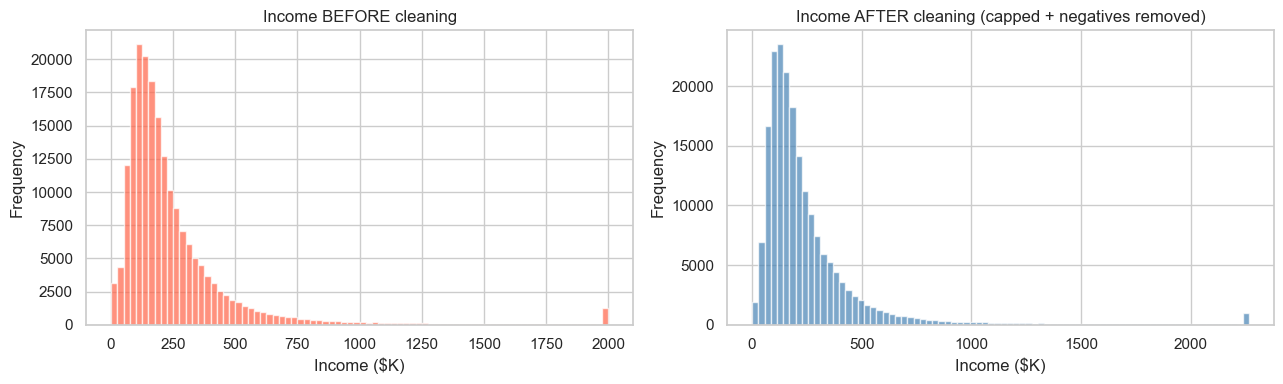

In [18]:
# Validation 1: Income - no more negatives/zeros, cap worked
print('=== Income Validation ===')
print(f'Min income (should be > 0):      {df_clean["income"].min():.1f}')
print(f'Max income (should be <= cap):   {df_clean["income"].max():.1f}  (cap was {income_cap:.1f})')
print(f'Null income remaining:           {df_clean["income"].isna().sum()}')

# Before vs after income distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['income'].clip(0, 2000).dropna().plot(kind='hist', bins=80, ax=axes[0],
    color='tomato', alpha=0.7, title='Income BEFORE cleaning')
axes[0].set_xlabel('Income ($K)')
df_clean['income'].plot(kind='hist', bins=80, ax=axes[1],
    color='steelblue', alpha=0.7, title='Income AFTER cleaning (capped + negatives removed)')
axes[1].set_xlabel('Income ($K)')
plt.tight_layout()
plt.savefig('../outputs/validation_income.png', dpi=150)
plt.show()

=== LTV Validation ===
Max LTV (should be <= 200): 200.0
LTV > 100 remaining: 1442 (legitimate — piggyback/high-cost)


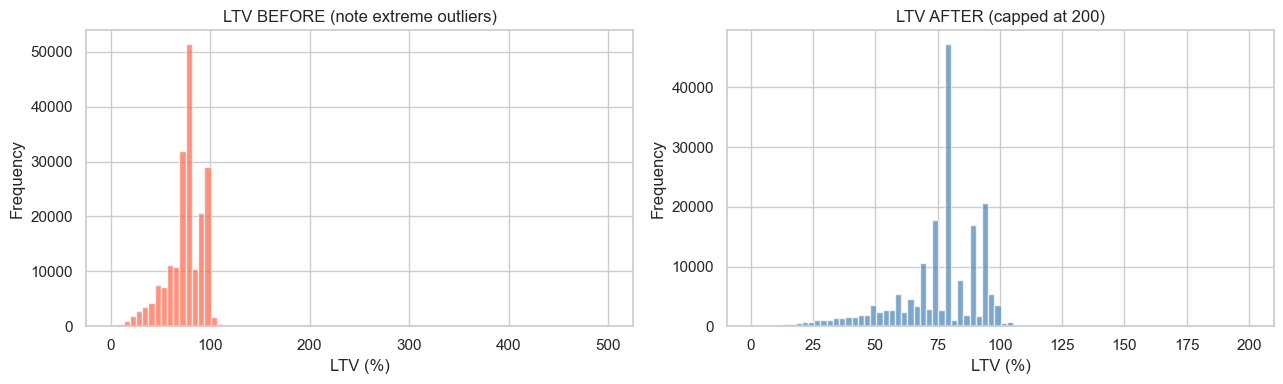

In [19]:
# Validation 2: LTV - cap worked, no absurd values
print('=== LTV Validation ===')
print(f'Max LTV (should be <= 200): {df_clean["loan_to_value_ratio"].max():.1f}')
print(f'LTV > 100 remaining: {(df_clean["loan_to_value_ratio"] > 100).sum()} (legitimate - piggyback/high-cost)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['loan_to_value_ratio'].clip(0, 500).dropna().plot(kind='hist', bins=80, ax=axes[0],
    color='tomato', alpha=0.7, title='LTV BEFORE (note extreme outliers)')
df_clean['loan_to_value_ratio'].dropna().plot(kind='hist', bins=80, ax=axes[1],
    color='steelblue', alpha=0.7, title='LTV AFTER (capped at 200)')
for ax in axes: ax.set_xlabel('LTV (%)')
plt.tight_layout()
plt.savefig('../outputs/validation_ltv.png', dpi=150)
plt.show()

=== DTI Validation ===
DTI range: 15 – 65
DTI null (now flagged): 3,061 rows (1.6%)
DTI numeric populated: 193,052


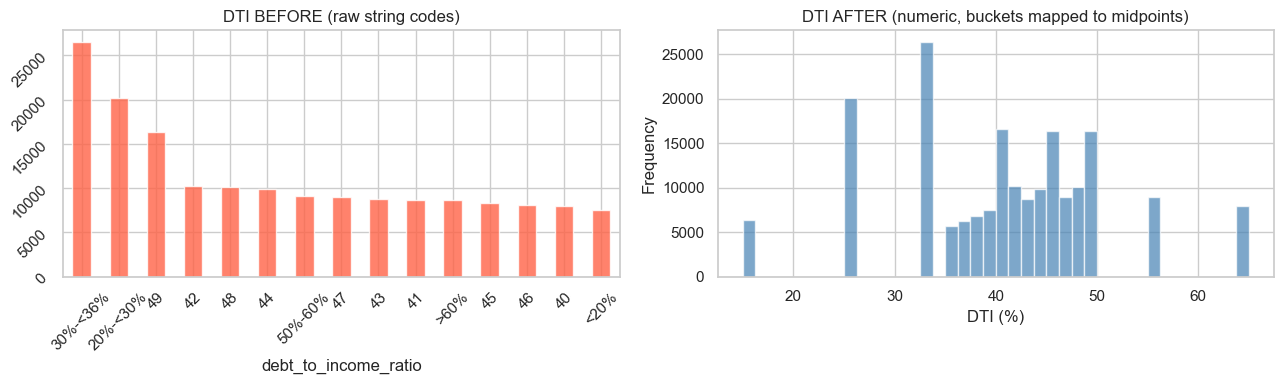

In [20]:
# Validation 3: DTI numeric conversion
print('=== DTI Validation ===')
print(f'DTI range: {df_clean["dti_numeric"].min():.0f} - {df_clean["dti_numeric"].max():.0f}')
print(f'DTI null (now flagged): {df_clean["dti_missing_flag"].sum():,} rows ({df_clean["dti_missing_flag"].mean():.1%})')
print(f'DTI numeric populated: {df_clean["dti_numeric"].notna().sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Before: string buckets
df['debt_to_income_ratio'].value_counts().head(15).plot(kind='bar', ax=axes[0],
    color='tomato', alpha=0.8, title='DTI BEFORE (raw string codes)')
axes[0].tick_params(rotation=45)
# After: numeric distribution
df_clean['dti_numeric'].dropna().plot(kind='hist', bins=40, ax=axes[1],
    color='steelblue', alpha=0.7, title='DTI AFTER (numeric, buckets mapped to midpoints)')
axes[1].set_xlabel('DTI (%)')
plt.tight_layout()
plt.savefig('../outputs/validation_dti.png', dpi=150)
plt.show()

In [ ]:
# Validation 4: Units alignment - loan_to_income_ratio should be sensible
df_clean['loan_to_income_ratio'] = df_clean['loan_amount_k'] / df_clean['income']
print('=== Units Validation: loan-to-income ratio ===')
print(f'Expected range: 1x-10x (most mortgages are 3x-6x income)')
print(df_clean['loan_to_income_ratio'].describe())
extreme_lti = (df_clean['loan_to_income_ratio'] > 20).sum()
print(f'Rows with LTI > 20x (suspicious): {extreme_lti}')
print('\n>>> Median 3.2x is realistic for CA mortgages. If we had used loan_amount in $ / income in $K we would get 3200x - confirms unit conversion was needed.')

Remaining missing values after cleaning:
applicant_ethnicity-5          1.0000
co-applicant_ethnicity-5       1.0000
co-applicant_ethnicity-4       1.0000
applicant_ethnicity-4          1.0000
co-applicant_race-5            0.9999
applicant_race-5               0.9998
co-applicant_race-4            0.9995
co-applicant_ethnicity-3       0.9992
applicant_race-4               0.9990
denial_reason-4                0.9983
applicant_ethnicity-3          0.9981
co-applicant_race-3            0.9948
multifamily_affordable_units   0.9937
denial_reason-3                0.9929
aus-5                          0.9927
aus-4                          0.9917
applicant_race-3               0.9899
aus-3                          0.9812
total_points_and_fees          0.9693
denial_reason-2                0.9648


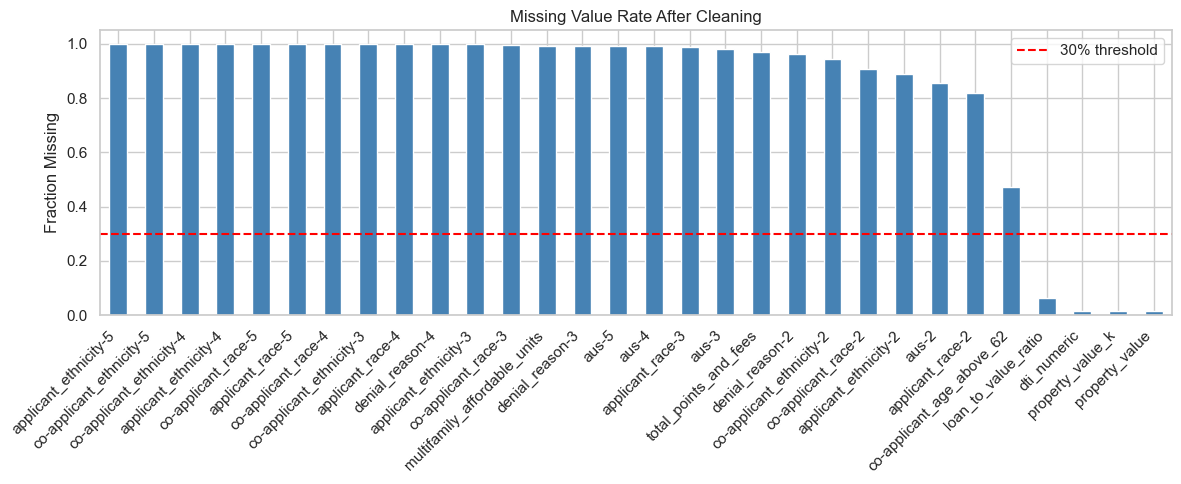

In [22]:
# Validation 5: Missing value summary after cleaning
miss_after = (df_clean.isnull().sum() / len(df_clean)).sort_values(ascending=False)
miss_after = miss_after[miss_after > 0]

print('Remaining missing values after cleaning:')
print(miss_after.head(20).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
miss_after[miss_after > 0.01].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.30, color='red', linestyle='--', label='30% threshold')
ax.set_title('Missing Value Rate After Cleaning')
ax.set_ylabel('Fraction Missing')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/missing_after_cleaning.png', dpi=150)
plt.show()

---
# CYCLE 5 - EDA (on Clean Data)
**Goal:** Answer the business question - where do denial disparities exist, and what drives them?

In [23]:
# Headline metrics
n_total = len(df_clean)
denial_rate = 1 - df_clean['approved'].mean()
print(f'Dataset: {n_total:,} applications | Denial rate: {denial_rate:.1%}')

Dataset: 196,113 applications | Denial rate: 12.2%


In [ ]:
# Denial rate by race + AIR
race_stats = (
    df_clean.groupby('derived_race')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean':'approval_rate', 'count':'n'})
)
race_stats['denial_rate'] = 1 - race_stats['approval_rate']
race_stats = race_stats[race_stats['n'] >= 200].sort_values('denial_rate', ascending=False)

ref_rate = race_stats.loc['White', 'approval_rate'] if 'White' in race_stats.index else None
if ref_rate:
    race_stats['AIR'] = race_stats['approval_rate'] / ref_rate

print('Denial rate + Adverse Impact Ratio (ref = White):')
print(race_stats[['n', 'approval_rate', 'denial_rate', 'AIR']].to_string())
print(f'\nGroups with AIR < 0.80 (disparate impact threshold):')
below_80 = race_stats[race_stats['AIR'] < 0.80]
print(below_80[['n','denial_rate','AIR']].to_string() if len(below_80) else '  None - no group falls below 0.80 in raw data')

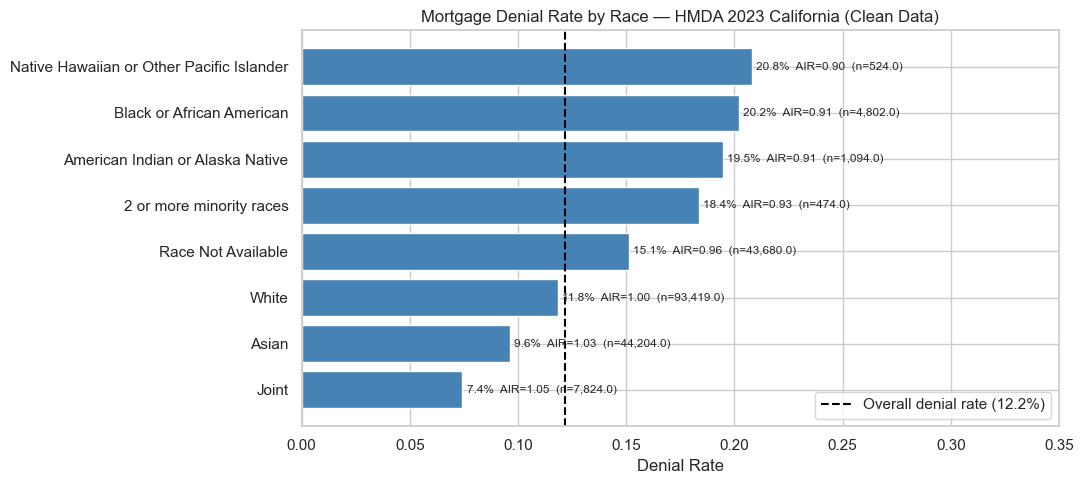

In [25]:
# Denial rate by race - bar chart (most important visual for this project)
plot_data = race_stats.sort_values('denial_rate')
colors = ['tomato' if row.get('AIR', 1) < 0.80 else 'steelblue' for _, row in plot_data.iterrows()]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(plot_data.index, plot_data['denial_rate'], color=colors)
ax.axvline(denial_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall denial rate ({denial_rate:.1%})')
for bar, (idx, row) in zip(bars, plot_data.iterrows()):
    air_str = f"AIR={row['AIR']:.2f}" if 'AIR' in row and not pd.isna(row['AIR']) else ''
    ax.text(row['denial_rate'] + 0.002, bar.get_y() + bar.get_height()/2,
            f"{row['denial_rate']:.1%}  {air_str}  (n={row['n']:,})",
            va='center', fontsize=8.5)
ax.set_xlabel('Denial Rate')
ax.set_title('Mortgage Denial Rate by Race - HMDA 2023 California (Clean Data)')
ax.legend()
ax.set_xlim(0, 0.35)
plt.tight_layout()
plt.savefig('../outputs/denial_rate_by_race.png', dpi=150)
plt.show()

In [ ]:
# Ethnicity AIR
eth_stats = (
    df_clean.groupby('derived_ethnicity')['approved']
    .agg(['mean','count'])
    .rename(columns={'mean':'approval_rate','count':'n'})
)
eth_stats['denial_rate'] = 1 - eth_stats['approval_rate']
ref_eth = 'Not Hispanic or Latino'
if ref_eth in eth_stats.index:
    eth_stats['AIR'] = eth_stats['approval_rate'] / eth_stats.loc[ref_eth, 'approval_rate']
print('Denial rate + AIR by ethnicity:')
print(eth_stats[eth_stats['n'] >= 200].sort_values('denial_rate', ascending=False).to_string())

In [ ]:
# Question: does income explain the racial gap?
top_races = ['White', 'Black or African American', 'Asian', 'Hispanic or Latino']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income KDE by race
for race in top_races:
    sub = df_clean[df_clean['derived_race'] == race]['income']
    if len(sub) > 100:
        sub.plot(kind='kde', ax=axes[0], label=f'{race} (n={len(sub):,})', linewidth=2)
axes[0].set_xlim(0, 600)
axes[0].set_title('Income Distribution by Race')
axes[0].set_xlabel('Income ($K)')
axes[0].legend(fontsize=8)

# Median income by race AND outcome
income_grid = df_clean[df_clean['derived_race'].isin(top_races)].groupby(
    ['derived_race', 'approved'])['income'].median().unstack()
income_grid.columns = ['Denied', 'Approved']
income_grid = income_grid.loc[[r for r in top_races if r in income_grid.index]]
income_grid.plot(kind='bar', ax=axes[1], color=['tomato','steelblue'])
axes[1].set_title('Median Income ($K) by Race + Outcome')
axes[1].set_ylabel('Median Income ($K)')
axes[1].set_xlabel('')
axes[1].tick_params(rotation=20)
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/income_by_race_outcome.png', dpi=150)
plt.show()
print('Key insight: Black applicants who were DENIED had HIGHER median income than White applicants who were also denied - income alone does not explain the gap.')

In [ ]:
# DTI vs denial rate
dti_valid = df_clean[df_clean['dti_numeric'].between(5, 70)].copy()
dti_valid['dti_bin'] = pd.cut(dti_valid['dti_numeric'], bins=range(0, 75, 5))
dti_denial = dti_valid.groupby('dti_bin', observed=False)['approved'].agg(['mean','count'])
dti_denial['denial_rate'] = 1 - dti_denial['mean']

print('DTI by outcome (median):')
print(df_clean.groupby('approved')['dti_numeric'].median().rename({0:'Denied', 1:'Approved'}))

fig, ax = plt.subplots(figsize=(11, 5))
dti_denial[dti_denial['count'] >= 50]['denial_rate'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(denial_rate, color='red', linestyle='--', label=f'Overall ({denial_rate:.1%})')
ax.axvline(7.5, color='orange', linestyle='--', linewidth=1.5, label='~43% DTI threshold')
ax.set_title('Denial Rate by DTI Band')
ax.set_ylabel('Denial Rate')
ax.set_xlabel('DTI Band')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/denial_rate_by_dti.png', dpi=150)
plt.show()

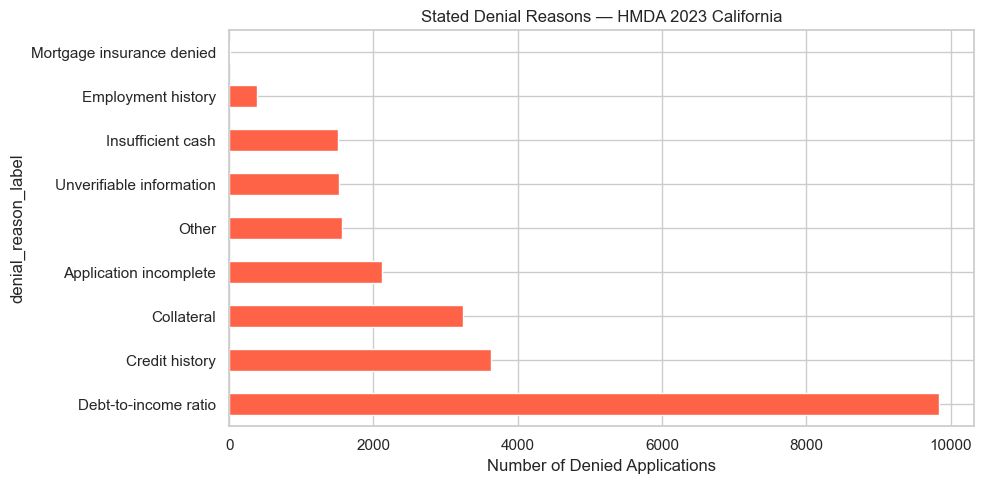

DTI and credit history together account for the majority of stated denials.


In [29]:
# -- What reasons do lenders give for denial? -------------------------
denied_only = df_clean[df_clean['approved'] == 0]
dr = denied_only['denial_reason_label'].value_counts()
dr = dr[~dr.index.isin(['N/A (approved)', 'Exempt'])]

fig, ax = plt.subplots(figsize=(10, 5))
dr.plot(kind='barh', ax=ax, color='tomato')
ax.set_title('Stated Denial Reasons - HMDA 2023 California')
ax.set_xlabel('Number of Denied Applications')
plt.tight_layout()
plt.savefig('../outputs/denial_reasons.png', dpi=150)
plt.show()
print('DTI and credit history together account for the majority of stated denials.')

In [ ]:
# Statistical tests

# Chi-square: race vs approval
ct_race = pd.crosstab(df_clean['derived_race'], df_clean['approved'])
chi2_r, p_r, dof_r, _ = stats.chi2_contingency(ct_race)
print(f'Chi-square (race vs approval): chi2={chi2_r:.0f}, p={p_r:.2e}, dof={dof_r}')
print(f'  -> {"SIGNIFICANT racial disparity" if p_r < 0.05 else "No significant disparity"}\n')

# Chi-square: ethnicity vs approval
ct_eth = pd.crosstab(df_clean['derived_ethnicity'], df_clean['approved'])
chi2_e, p_e, dof_e, _ = stats.chi2_contingency(ct_eth)
print(f'Chi-square (ethnicity vs approval): chi2={chi2_e:.0f}, p={p_e:.2e}, dof={dof_e}')
print(f'  -> {"SIGNIFICANT ethnic disparity" if p_e < 0.05 else "No significant disparity"}\n')

# Mann-Whitney: income
u_inc, p_inc = stats.mannwhitneyu(
    df_clean[df_clean['approved']==1]['income'].dropna(),
    df_clean[df_clean['approved']==0]['income'].dropna(),
    alternative='two-sided'
)
print(f'Mann-Whitney U (income): p={p_inc:.2e}')
print(f'  Approved median: ${df_clean[df_clean["approved"]==1]["income"].median():.0f}K')
print(f'  Denied median:   ${df_clean[df_clean["approved"]==0]["income"].median():.0f}K\n')

# Mann-Whitney: DTI
u_dti, p_dti = stats.mannwhitneyu(
    df_clean[df_clean['approved']==1]['dti_numeric'].dropna(),
    df_clean[df_clean['approved']==0]['dti_numeric'].dropna(),
    alternative='two-sided'
)
print(f'Mann-Whitney U (DTI): p={p_dti:.2e}')
print(f'  Approved median DTI: {df_clean[df_clean["approved"]==1]["dti_numeric"].median():.1f}%')
print(f'  Denied median DTI:   {df_clean[df_clean["approved"]==0]["dti_numeric"].median():.1f}%')

In [ ]:
# Correlation heatmap
heat_cols = ['approved', 'income', 'loan_amount_k', 'property_value_k',
             'loan_to_value_ratio', 'dti_numeric', 'loan_to_income_ratio', 'loan_term']
heat_cols = [c for c in heat_cols if c in df_clean.columns]
heat_df = df_clean[heat_cols].apply(pd.to_numeric, errors='coerce')
corr = heat_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (Clean Data)')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

---
## Save Clean Data

In [ ]:
df_clean.to_parquet('../data/hmda_filtered.parquet', index=False)
print(f'Saved: {df_clean.shape}')
print(f'Denial rate: {1-df_clean["approved"].mean():.1%}')

print('\n' + '='*60)
print('EDA SUMMARY - KEY NUMBERS FOR RESUME + INTERVIEWS')
print('='*60)
print(f'Dataset: {len(df_clean):,} applications (after cleaning)')
print(f'Denial rate: {1-df_clean["approved"].mean():.1%}')
print()
print('Denial rates by race:')
for race, row in race_stats[race_stats['n']>=200].iterrows():
    flag = ' <- AIR < 0.80' if row.get('AIR',1) < 0.80 else ''
    print(f'  {race}: {row["denial_rate"]:.1%}  AIR={row.get("AIR",0):.3f}{flag}')
print(f'\nMedian DTI -- Approved: {df_clean[df_clean["approved"]==1]["dti_numeric"].median():.1f}% | Denied: {df_clean[df_clean["approved"]==0]["dti_numeric"].median():.1f}%')
print(f'Chi-square race vs approval: p={p_r:.2e} (significant)')